# Analysing the types of early contact events between the fly and ball

Questions:

* do flies need to do some pattern of pushing before they can do a major push?
* are some types of pushing better for doing a major event or not?

To answer these questions - look at the types of pushing for empty-split (control) flies until they do a major push, which shows that they can push the ball effectively

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import pathlib

import matplotlib
import numpy as np
import plotnine as p9
import polars as pl
from matplotlib import pyplot as plt

matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"]
matplotlib.rcParams["pdf.fonttype"] = 42

# setup output dir for videos (only works if run in vscode, otherwise modify)
output_dir = pathlib.Path(
    f"../../outputs/figures/{pathlib.Path(__vsc_ipynb_file__).stem}"  # type: ignore
)
os.makedirs(output_dir, exist_ok=True)

## Loading contact classification data


In [2]:
from ball_pushing_high_res.df_utils import until_major_push

results_all = pl.read_csv(
    output_dir / "../../../outputs-saved/empty-split-early-push-classifications.csv",
    columns=range(16),
).filter(
    pl.col("contact_type").str.contains("matched").not_(),
    pl.col("contact_type") != "none",
)
results_all

line,vid,corridor,view,start_index,end_contact_index,end_index,len,ball_pos_start,ball_pos_end,head_pos_start,head_pos_end,net_ball_dist,total_ball_dist,efficiency,contact_type
str,str,i64,str,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str
"""empty-split""","""20250926-144058""",6,"""bottom""",1240,1254,1254,15,4.79,4.8,3.93,3.98,0.01,0.02,0.33,"""Two leg"""
"""empty-split""","""20250926-144058""",6,"""bottom""",1265,1290,1318,54,4.8,7.05,3.86,4.36,2.25,2.28,0.99,"""One leg"""
"""empty-split""","""20250930-180612""",4,"""top""",466,661,678,213,4.8,8.41,3.85,5.61,3.61,5.27,0.69,"""Rearing"""
"""empty-split""","""20250930-180612""",6,"""top""",477,568,568,92,5.15,4.91,4.33,3.78,-0.24,1.12,0.21,"""Rearing"""
"""empty-split""","""20250930-180612""",6,"""top""",669,895,895,227,5.03,6.42,3.84,5.63,1.39,4.47,0.31,"""Rearing"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""empty-split""","""20251003-150058""",1,"""top""",52354,52530,52530,177,4.13,4.13,3.13,3.35,0.01,0.04,0.2,"""Rearing"""
"""empty-split""","""20251003-150058""",1,"""top""",52541,52813,52813,273,4.13,4.13,2.89,2.97,0.0,0.02,0.0,"""Rearing"""
"""empty-split""","""20251003-150058""",1,"""top""",60380,60510,60510,131,4.13,4.13,3.04,2.58,0.0,0.02,0.0,"""Two leg"""


In [3]:
results_grouped = (
    results_all.group_by("vid", "corridor", maintain_order=True)
    .agg(
        "contact_type",
        "net_ball_dist",
        num_events=pl.len(),
        major_push_index=pl.col("len").filter(until_major_push).len() - 1,
    )
    .with_columns(
        # we don't have a novel major event if there's a hybrid contact event
        novel_major=pl.col("contact_type")
        .list.slice(0, pl.col("contact_type").list.len() - 1)
        .list.contains(pl.col("contact_type").list.last())
        .not_()
        & pl.col("contact_type").list.last().str.contains("[&]").not_(),
    )
    .sort("num_events", maintain_order=True)
)
results_grouped

vid,corridor,contact_type,net_ball_dist,num_events,major_push_index,novel_major
str,i64,list[str],list[f64],u32,u32,bool
"""20250930-180612""",4,"[""Rearing""]",[3.61],1,0,true
"""20250926-144058""",6,"[""Two leg"", ""One leg""]","[0.01, 2.25]",2,1,true
"""20250930-180612""",6,"[""Rearing"", ""Rearing""]","[-0.24, 1.39]",2,1,false
"""20250813-170725""",3,"[""One leg"", ""Rearing""]","[-0.14, 10.08]",2,1,true
"""20251003-150058""",2,"[""One leg"", ""Rearing""]","[-0.01, 1.44]",2,1,true
…,…,…,…,…,…,…
"""20250926-144058""",1,"[""One leg"", ""One leg"", … ""Rearing""]","[0.02, -0.02, … 3.64]",54,53,false
"""20250930-193107""",6,"[""One leg"", ""One leg"", … ""Rearing""]","[-0.49, 0.02, … 1.56]",54,53,true
"""20250926-173050""",5,"[""One leg"", ""One leg"", … ""Rearing""]","[0.01, -0.01, … 1.37]",55,54,false


In [4]:
unique_types = (
    pl.concat(
        [
            results_all.get_column("contact_type"),
            results_all.select(
                type=pl.col("contact_type").str.split(" & ").explode()
            ).get_column("type"),
        ]
    )
    .unique()
    .to_frame()
    .sort(
        pl.col("contact_type").str.len_chars(),
        pl.col("contact_type"),
        maintain_order=True,
    )
    .with_row_index()
)
unique_types

index,contact_type
u32,str
0,"""Head"""
1,"""One leg"""
2,"""Rearing"""
3,"""Two leg"""
4,"""Head & One leg"""
…,…
7,"""One leg & Head"""
8,"""Two leg & Head"""
9,"""One leg & Rearing"""


## What types of pushes does each fly do until its first major push?

In [5]:
from ball_pushing_high_res.df_utils import pad_list_column_to_length

max_num_events = results_grouped.select(pl.col("contact_type").list.len()).max().item()

results_padded = pad_list_column_to_length(
    pad_list_column_to_length(results_grouped, "contact_type", None, max_num_events),
    "net_ball_dist",
    None,
    max_num_events,
)

type_to_index_map = dict(
    zip(unique_types.get_column("contact_type"), unique_types.get_column("index"))
)

# separate out the hybrid events for easier plotting and convert to numbers
first = (
    results_padded.select(
        pl.col("contact_type")
        .list.eval(pl.element().str.split(" & ").list.first())
        .list.to_struct(upper_bound=max_num_events),
    )
    .unnest("contact_type")
    .select(pl.all().replace(type_to_index_map))
)
last = (
    results_padded.select(
        pl.col("contact_type")
        .list.eval(pl.element().str.split(" & ").list.last())
        .list.to_struct(upper_bound=max_num_events),
    )
    .unnest("contact_type")
    .select(pl.all().replace(type_to_index_map))
)
distances = results_padded.select(
    pl.col("net_ball_dist").list.to_struct(upper_bound=max_num_events),
).unnest("net_ball_dist")

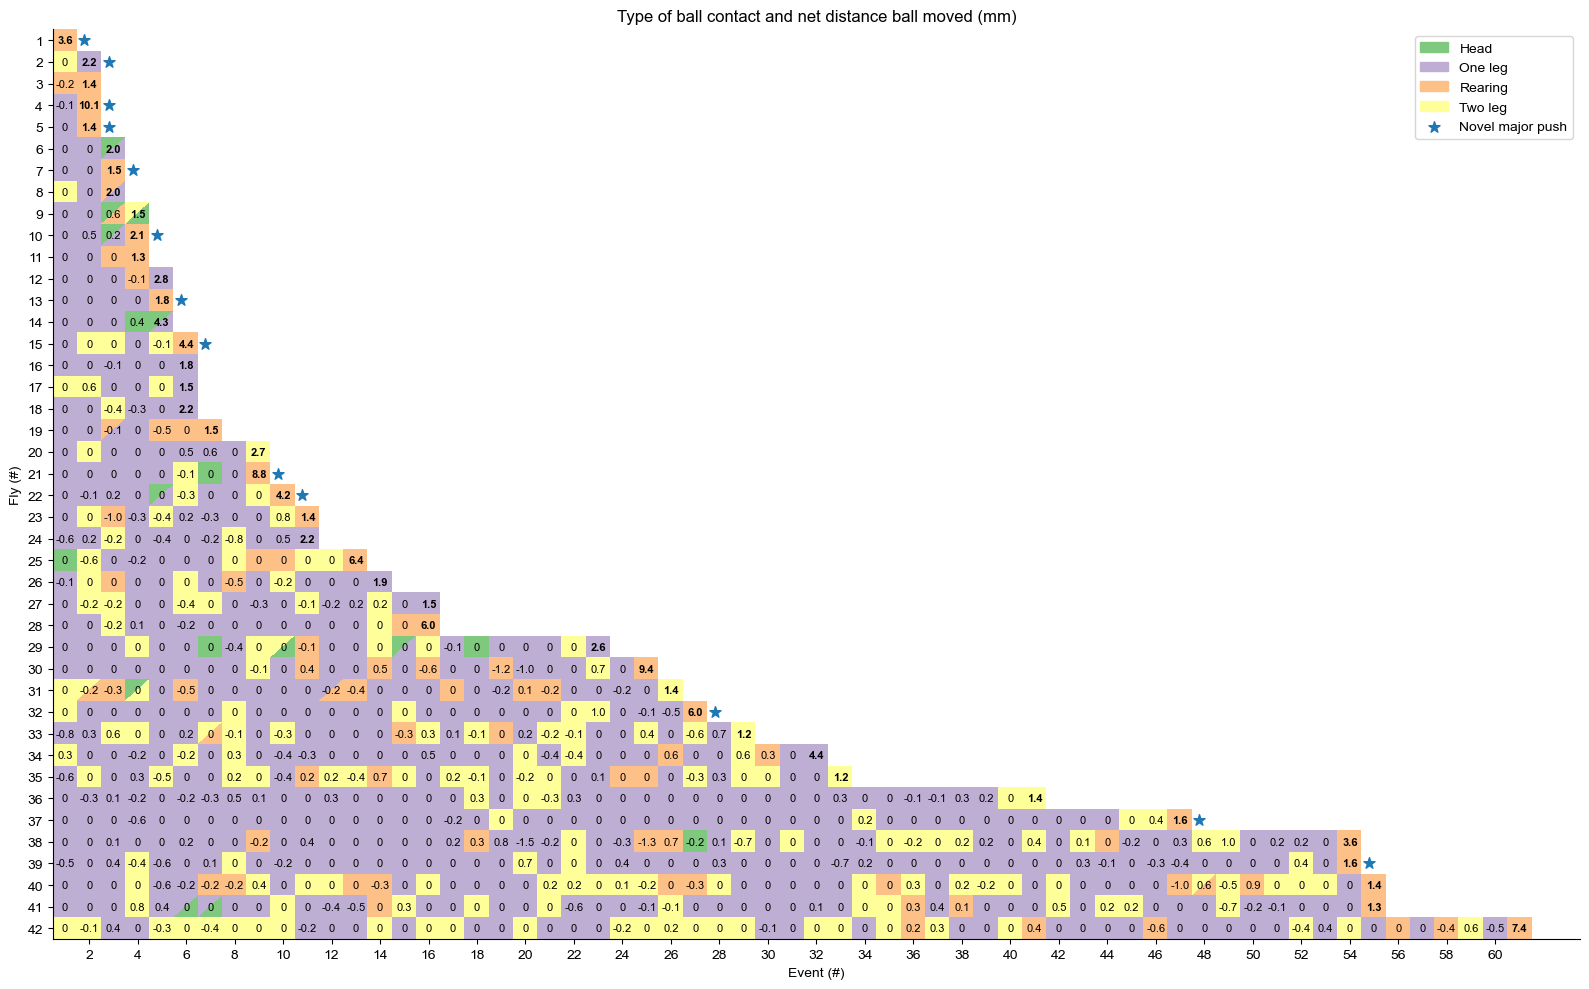

In [6]:
from ball_pushing_high_res.plot_utils import (
    add_to_legend,
    hide_axes_top_right,
    plot_annotated_heatmap_split,
    xticks_show_nth,
)

plt.figure(figsize=(16, 10))
# setting vmax to 7 gives a nicer colour range
plot_annotated_heatmap_split(
    np.dstack((first.to_numpy(), last.to_numpy())).astype(np.float64),
    [f"{n}" for n in range(1, first.shape[0] + 1)],
    [str(x) for x in range(1, first.shape[1] + 1)],
    distances.to_numpy(),
    vmax=7,
    annotations_formatter=lambda val: "0" if abs(val) <= 0.1 else f"{val:.1f}",
    annotations_formatter_kwargs=lambda val: {
        "weight": "bold" if val >= 1.2 else "normal",
        "size": 8,
    },
    legend_entries=dict(
        unique_types[:4].select("contact_type", "index").iter_rows()
    ),  # don't show the combined types
)
novel_major = results_grouped.with_row_index().filter("novel_major")
novel_markers = plt.scatter(
    novel_major["major_push_index"] + 1.3,
    novel_major["index"] + 0.5,
    s=70,
    marker="*",
)
add_to_legend([novel_markers], ["Novel major push"], "after")

xticks_show_nth(2, start_offset=1)
hide_axes_top_right()

plt.title("Type of ball contact and net distance ball moved (mm)")
plt.xlabel("Event (#)")
plt.ylabel("Fly (#)")
plt.xlim(plt.xlim()[0], plt.xlim()[1] + 2)
plt.tight_layout()
plt.savefig(output_dir / "empty-split early pushes figure.pdf")
plt.show()

## How do the different types of pushing events compare?

Do some types tend to be longer or shorter contact events, and lead to shorter or longer ball movements?

### Distances for each event type

/home/nely/micromamba/envs/sleap_io/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 8 x 4 in image.
/home/nely/micromamba/envs/sleap_io/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../outputs/notebooks/early-contact-event-classification-empty-split/ball_pushing_types_distance.pdf


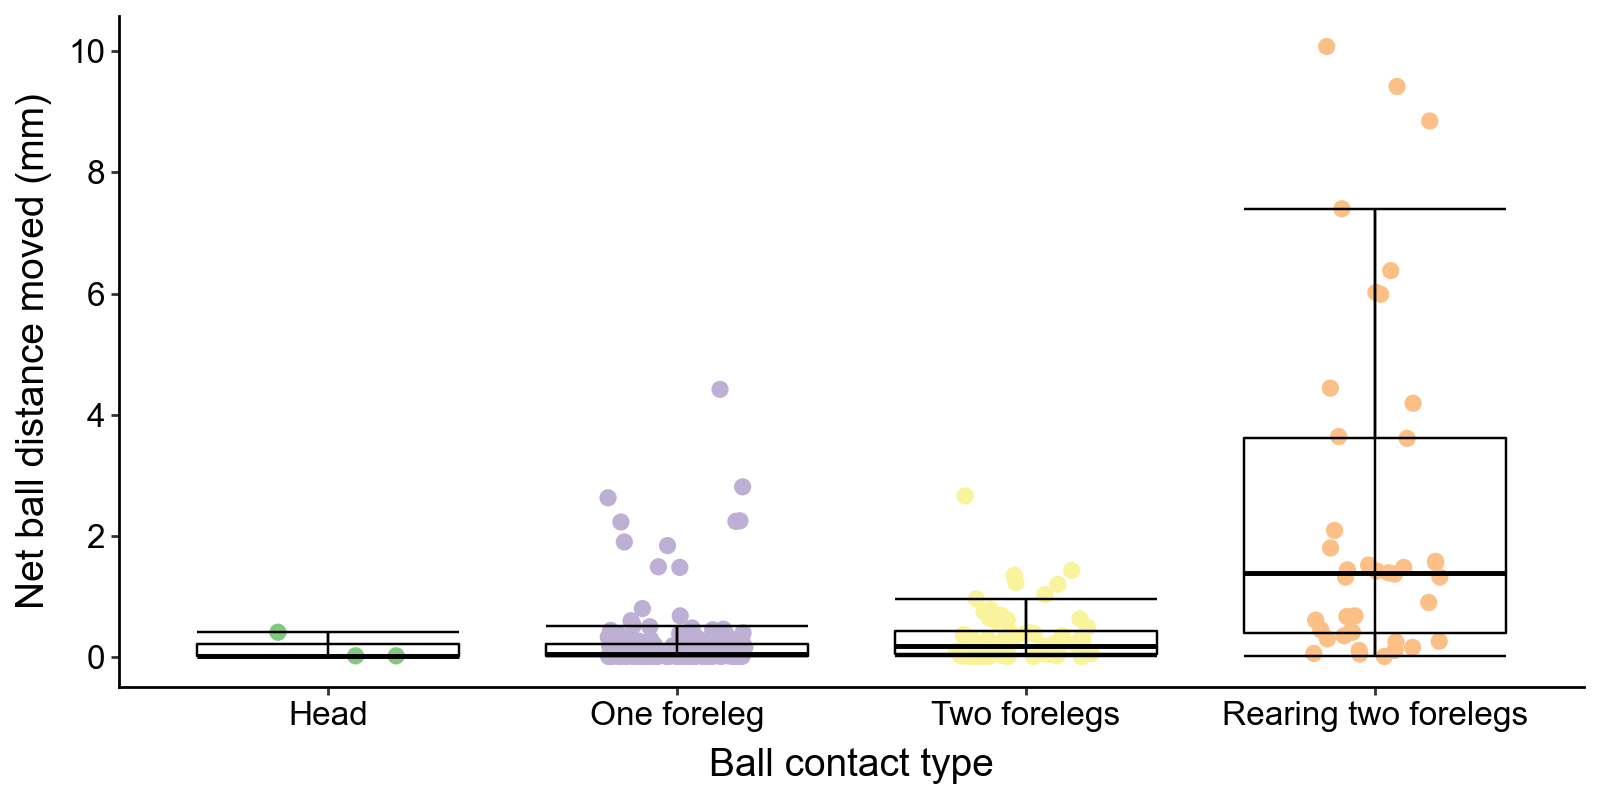

In [7]:
from ball_pushing_high_res.plot_utils import paper_theme_plotnine

push_types_no_hybrids_pushes_only = (
    results_all.filter(pl.col("contact_type").str.contains("[&]").not_())
    .with_columns(push=pl.col("net_ball_dist") > 0)
    .filter(pl.col("push"))
    .with_columns(pl.col("contact_type").str.to_titlecase())
)

push_types = {
    "Head": "Head",
    "One Leg": "One foreleg",
    "Two Leg": "Two forelegs",
    "Rearing": "Rearing two forelegs",
}

dist_plot = (
    p9.ggplot(
        push_types_no_hybrids_pushes_only.with_columns(
            contact_type=pl.col("contact_type").replace(push_types)
        ).cast({"contact_type": pl.Enum(push_types.values())}),
        p9.aes(x="contact_type", y="net_ball_dist"),
    )
    + p9.geom_jitter(
        width=0.2,
        height=0,
        random_state=42,
        mapping=p9.aes(color="contact_type"),
        size=2.5,
        show_legend=False,
    )
    + p9.stat_boxplot(geom="errorbar", size=0.5, color="black", show_legend=False)
    + p9.geom_boxplot(
        outlier_shape="", alpha=0, size=0.5, color="black", show_legend=False
    )
    + p9.theme(figure_size=(10, 6))
    + p9.labs(title="Ball movement distance by type of contact event")
    # + p9.scale_y_continuous(limits=(-2, 5), oob=lambda x, _: x)
    + p9.labs(x="Ball contact type", y="Net ball distance moved (mm)")
    + p9.scale_color_manual(["#82c87f", "#beafd5", "#f9f49b", "#fcc086"])
)
dist_plot_themed = (
    (dist_plot + paper_theme_plotnine)
    + p9.scale_y_continuous(breaks=range(0, 11, 2))
    + p9.theme(figure_size=(8, 4), plot_title=p9.element_blank())
)
dist_plot_themed.save(output_dir / "ball_pushing_types_distance.pdf")
dist_plot_themed.show()

In [8]:
import scipy.stats


def get_bootstrapped_confidence_interval_for_contact_type(contact_type: str):
    if contact_type == "Head":
        return None, None

    confidence_interval = scipy.stats.bootstrap(
        [
            push_types_no_hybrids_pushes_only.filter(contact_type=contact_type)
            .get_column("net_ball_dist")
            .to_numpy()
        ],
        np.median,
    )
    return (
        confidence_interval.confidence_interval.low,
        confidence_interval.confidence_interval.high,
    )


push_type_stats = (
    push_types_no_hybrids_pushes_only.group_by("contact_type")
    .agg(
        N=pl.len(),
        median_ball_distance=pl.col("net_ball_dist").median(),
    )
    .with_columns(
        pl.col("contact_type")
        .map_elements(
            get_bootstrapped_confidence_interval_for_contact_type,
            return_dtype=pl.Array(pl.Float64, 2),
        )
        .arr.to_struct(["confidence_interval_low", "confidence_interval_high"])
        .struct.unnest()
    )
)
push_type_stats

contact_type,N,median_ball_distance,confidence_interval_low,confidence_interval_high
str,u32,f64,f64,f64
"""Head""",3,0.02,null,null
"""Rearing""",40,1.38,0.64,1.57
"""Two Leg""",68,0.185,0.13,0.3
"""One Leg""",150,0.055,0.025,0.08


In [9]:
from ball_pushing_high_res.stat_utils import permutation_test_df

p_values = {}
test_statistics = {}
for n1 in range(1, len(push_types) - 1):
    for n2 in range(n1 + 1, len(push_types)):
        group1 = list(push_types.keys())[n1]
        group2 = list(push_types.keys())[n2]
        comparison = f"{group1} vs {group2}"

        result = permutation_test_df(
            push_types_no_hybrids_pushes_only,
            "contact_type",
            group1,
            group2,
            "net_ball_dist",
            statistic=np.median,
        )
        p_values[comparison] = result.pvalue
        test_statistics[comparison] = result.statistic

p_values_fdr = dict(
    zip(p_values.keys(), scipy.stats.false_discovery_control(list(p_values.values())))
)

for n1 in range(1, len(push_types) - 1):
    for n2 in range(n1 + 1, len(push_types)):
        group1 = list(push_types.keys())[n1]
        group2 = list(push_types.keys())[n2]
        comparison = f"{group1} vs {group2}"

        group1_median = (
            push_types_no_hybrids_pushes_only.filter(contact_type=group2)
            .get_column("net_ball_dist")
            .median()
        ) or 0
        group2_median = (
            push_types_no_hybrids_pushes_only.filter(contact_type=group1)
            .get_column("net_ball_dist")
            .median()
        ) or 0
        print(
            f"{comparison}: median_difference = {group2_median - group1_median}; P (FDR corrected) = {p_values_fdr[comparison]:.5f}"
        )

One Leg vs Two Leg: median_difference = -0.13; P (FDR corrected) = 0.00120
One Leg vs Rearing: median_difference = -1.325; P (FDR corrected) = 0.00030
Two Leg vs Rearing: median_difference = -1.1949999999999998; P (FDR corrected) = 0.00030
